### Apresentação

Este notebook tem como objetivo mostrar como aplicar a interpolação em amostras espaçadas, permitindo a geração de novos dados com base em pontos já conhecidos. Aqui usaremos a trajetória de um poço com 79 pontos conhecidos e criaremos um eixo contínuo de profundidade medida (MD), ancoraremos nele os pontos reais de profundidade vertical (TVD) e usaremos interpolação linear para gerar um perfil MD–TVD completo e sintético.

Por fim, descobriremos quais seriam as profundidades verticais de amostras de pressão que originalmente só tem informação de profundidade medida.

### Descrição do Dado

O poço direcional utilizado neste projeto pertence à Bacia de Alagoas e suas informações e dados podem ser baixados gratuitamente no REATE (https://reate.cprm.gov.br/anp/TERRESTRE). Para este notebook, usaremos apenas seu direcional, que contém 79 amostras de profundidade.

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d        # função para fazer interpolação de valores
import matplotlib.pyplot as plt

In [ ]:
# Caminho da pasta principal
caminho = "C:/Users/lucas.aguiar/Desktop/Pastas/B2S/notebooks_exclusivos/4_interpolacao_profundidade/"

In [ ]:
# Importação do arquivo com trajetória
direcional = pd.read_csv(caminho + "7-anb-1d-al_brsa_direc.txt", sep=r"\s+", skiprows=4, encoding="latin1", decimal=",", thousands=".")
direcional.head(10)

,Trajet.,Prof.Med.(m),Inclinação(°),Direção,Prof.Vertical(m),Cota(M),Afast.(m),Coord.N/S,Coord.L/W,UTMNorte(m),UTMLeste(m),DogLegSev.(°/30m)
0,TIE-0,4.9,0.00,"N0,00E",4.90,113.30,0.00,0.00,0.00,8922211.00,821622.00,0.00
1,MWD,284.0,0.09,"S44,20E",284.00,-165.80,0.22,-0.16,0.15,8922210.84,821622.15,0.01
2,MWD,312.0,0.41,"N3,41W",312.00,-193.80,0.17,-0.07,0.16,8922210.93,821622.16,0.52
3,MWD,341.0,1.25,"N18,18W",341.00,-222.80,0.34,0.33,0.06,8922211.33,821622.06,0.89
4,MWD,370.0,1.95,"N27,53E",369.99,-251.79,1.09,1.07,0.19,8922212.07,821622.19,1.45
5,MWD,398.0,1.85,"N52,19E",397.97,-279.77,1.93,1.77,0.76,8922212.77,821622.76,0.88
6,MWD,436.0,1.13,"S68,65E",435.96,-317.76,2.57,2.01,1.60,8922213.01,821623.60,1.26
7,MWD,463.0,1.17,"S68,34E",462.95,-344.75,2.77,1.81,2.10,8922212.81,821624.10,0.04
8,MWD,491.0,1.05,"S62,35E",490.95,-372.75,3.04,1.59,2.59,8922212.59,821624.59,0.18
9,MWD,519.0,0.84,"S73,99E",518.95,-400.75,3.33,1.41,3.02,8922212.41,821625.02,0.30


In [ ]:
# Dimensões do dado (quantidade linhas e colunas)
direcional.shape

(79, 12)

In [ ]:
# Tipos de dados das colunas
direcional.dtypes

Trajet.               object
Prof.Med.(m)         float64
Inclinação(°)        float64
Direção               object
Prof.Vertical(m)     float64
Cota(M)              float64
Afast.(m)            float64
Coord.N/S            float64
Coord.L/W            float64
UTMNorte(m)          float64
UTMLeste(m)          float64
DogLegSev.(°/30m)    float64
dtype: object

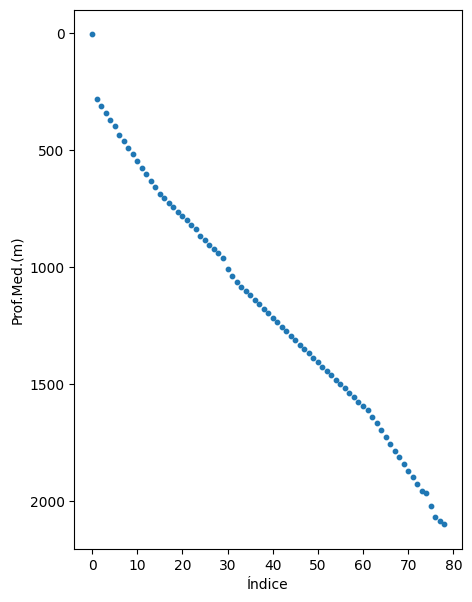

In [ ]:
# Visualização do dado espaçado
plt.figure(figsize=(5, 7))
plt.scatter(direcional.index, direcional["Prof.Med.(m)"], s=10)
plt.xlabel("Índice")
plt.ylabel("Prof.Med.(m)")
plt.gca().invert_yaxis()

In [ ]:
# Criação de coluna para manter dado original de profundidade
direcional["MD Original"] = direcional["Prof.Med.(m)"].copy()

In [ ]:
# Criação de sequência fictícia com intervalo de 0.1 m entre o mínimo e o máximo da coluna Prof.Med.(m)
novo_md = pd.DataFrame({"Prof.Med.(m)":np.arange(direcional["Prof.Med.(m)"].min(),
                                                 direcional["Prof.Med.(m)"].max(),
                                                 0.1)})
novo_md

,Prof.Med.(m)
0,4.9
1,5.0
2,5.1
3,5.2
4,5.3
...,...
20946,2099.5
20947,2099.6
20948,2099.7
20949,2099.8


In [ ]:
# Associação de dados originais ao MD prolongado em profundidades exatas ou aproximadas, de acordo com a tolerância estabelecida
direcional_completo = pd.merge_asof(novo_md,
                                    direcional,
                                    on="Prof.Med.(m)",
                                    tolerance=0.05,
                                    direction="nearest"
                                   )
direcional_completo

,Prof.Med.(m),Trajet.,Inclinação(°),Direção,Prof.Vertical(m),Cota(M),Afast.(m),Coord.N/S,Coord.L/W,UTMNorte(m),UTMLeste(m),DogLegSev.(°/30m),MD Original
0,4.9,TIE-0,0.0,"N0,00E",4.9,113.3,0.0,0.0,0.0,8922211.0,821622.0,0.0,4.9
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20946,2099.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20947,2099.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20948,2099.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20949,2099.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Seleção dos pontos com os valores já conhecidos de Prof.Vertical(m)
tvd_conhecido = direcional_completo.dropna(subset=['Prof.Vertical(m)'], axis=0)
tvd_conhecido

,Prof.Med.(m),Trajet.,Inclinação(°),Direção,Prof.Vertical(m),Cota(M),Afast.(m),Coord.N/S,Coord.L/W,UTMNorte(m),UTMLeste(m),DogLegSev.(°/30m),MD Original
0,4.9,TIE-0,0.00,"N0,00E",4.90,113.30,0.00,0.00,0.00,8922211.00,821622.00,0.00,4.9
2791,284.0,MWD,0.09,"S44,20E",284.00,-165.80,0.22,-0.16,0.15,8922210.84,821622.15,0.01,284.0
3071,312.0,MWD,0.41,"N3,41W",312.00,-193.80,0.17,-0.07,0.16,8922210.93,821622.16,0.52,312.0
3361,341.0,MWD,1.25,"N18,18W",341.00,-222.80,0.34,0.33,0.06,8922211.33,821622.06,0.89,341.0
3651,370.0,MWD,1.95,"N27,53E",369.99,-251.79,1.09,1.07,0.19,8922212.07,821622.19,1.45,370.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19511,1956.0,MWD,42.30,"S70,94E",1723.47,-1605.27,694.82,-121.33,684.14,8922089.67,822306.14,1.72,1956.0
19611,1966.0,MWD,42.51,"S70,80E",1730.85,-1612.65,701.48,-123.54,690.52,8922087.46,822312.52,0.69,1966.0
20181,2023.0,MWD,36.52,"S67,84E",1774.81,-1656.61,737.15,-136.28,724.44,8922074.72,822346.44,3.30,2023.0
20661,2071.0,MWD,32.26,"S66,56E",1814.41,-1696.21,763.68,-146.77,749.44,8922064.23,822371.44,2.70,2071.0


In [ ]:
# Função de interpolação + extrapolação linear
f_interp = interp1d(tvd_conhecido['Prof.Med.(m)'],
                    tvd_conhecido['Prof.Vertical(m)'],
                    kind='linear',                    # TVD varia linearmente entre pontos conhecidos
                    fill_value='extrapolate'          # permite estimar TVD fora do intervalo medido (topo/base).
                    )


In [ ]:
# Preenchimento do TVD em todo o seguimento que tem MD
direcional_completo['Prof.Vertical(m)'] = f_interp(direcional_completo['Prof.Med.(m)'])
direcional_completo

,Prof.Med.(m),Trajet.,Inclinação(°),Direção,Prof.Vertical(m),Cota(M),Afast.(m),Coord.N/S,Coord.L/W,UTMNorte(m),UTMLeste(m),DogLegSev.(°/30m),MD Original
0,4.9,TIE-0,0.0,"N0,00E",4.900000,113.3,0.0,0.0,0.0,8922211.0,821622.0,0.0,4.9
1,5.0,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5.1,NaN,NaN,NaN,5.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.2,NaN,NaN,NaN,5.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.3,NaN,NaN,NaN,5.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20946,2099.5,NaN,NaN,NaN,1838.533214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20947,2099.6,NaN,NaN,NaN,1838.617857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20948,2099.7,NaN,NaN,NaN,1838.702500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20949,2099.8,NaN,NaN,NaN,1838.787143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


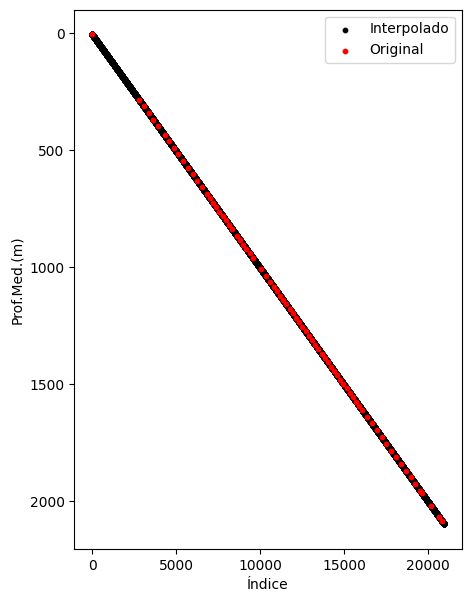

In [ ]:
# Visualização do dado preenchido
plt.figure(figsize=(5, 7))
plt.scatter(direcional_completo.index, direcional_completo["Prof.Med.(m)"], s=10, label="Interpolado", color="black")
plt.scatter(direcional_completo.index, direcional_completo["MD Original"], s=10, label="Original", color="red")
plt.xlabel("Índice")
plt.ylabel("Prof.Med.(m)")
plt.gca().invert_yaxis()
plt.legend()

In [ ]:
# Quantidade de amostras não nulas do novo dado
direcional_completo.notna().sum()

Prof.Med.(m)         20951
Trajet.                 78
Inclinação(°)           78
Direção                 78
Prof.Vertical(m)     20951
Cota(M)                 78
Afast.(m)               78
Coord.N/S               78
Coord.L/W               78
UTMNorte(m)             78
UTMLeste(m)             78
DogLegSev.(°/30m)       78
MD Original             78
dtype: int64

### Observação

Agora se você tiver algum dado indicado apenas em profundidade medida (ex: topos e bases de canhoneios ou dados de pressão), poderia fazer a associação ao direcional completo e ver qual seria a profundidade vertical desses dados.

In [ ]:
# Exemplo de dataframe com profundidades medidas de dados de pressão FICTÍCIOS
pressao = pd.DataFrame({"Prof.Med.(m)":[1451.4, 1579.5, 1600.0, 2003.2],
                        "Pressão(psi)":[1300, 1350, 1500, 1600]})
pressao

,Prof.Med.(m),Pressão(psi)
0,1451.4,1300
1,1579.5,1350
2,1600.0,1500
3,2003.2,1600


In [ ]:
# Associação de dados em profundidades próximas/exatas
pressao = pd.merge_asof(pressao,
                        direcional_completo[["Prof.Med.(m)","Prof.Vertical(m)"]],
                        on="Prof.Med.(m)",
                        tolerance=0.04,
                        direction="nearest"
                        )
pressao

,Prof.Med.(m),Pressão(psi),Prof.Vertical(m)
0,1451.4,1300,1349.871158
1,1579.5,1350,1454.487222
2,1600.0,1500,1470.955789
3,2003.2,1600,1759.539684
